In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [34]:
df_cdmx1 = pd.read_csv('./data/CDMX_2015_2020.csv')
df_cdmx2 = pd.read_csv('./data/CDMX_2020_2025.csv')

df_cuerna1 = pd.read_csv('./data/CUERNA_2015_2020.csv')
df_cuerna2 = pd.read_csv('./data/CUERNA_2020_2025.csv')

df_puebla1 = pd.read_csv('./data/PUEBLA_2015_2020.csv')
df_puebla2 = pd.read_csv('./data/PUEBLA_2020_2025.csv')

In [35]:
df_cdmx1 = df_cdmx1[df_cdmx1['DATE'] < '2020-01-01']
df_cuerna1 = df_cuerna1[df_cuerna1['DATE'] < '2020-01-01']
df_puebla1 = df_puebla1[df_puebla1['DATE'] < '2020-01-01']

In [61]:
df_general = pd.concat([df_cdmx1, df_cdmx2,
                        df_cuerna1, df_cuerna2,
                        df_puebla1, df_puebla2]).sort_values(by = 'DATE')

In [62]:
df_general = df_general.reset_index(drop = True)

In [63]:
df_general.drop(['TMAX_ATTRIBUTES', 'TMIN_ATTRIBUTES'], axis = 1, inplace = True)

In [64]:
df_general['TMAX'] = (df_general['TMAX'] - 32)/1.8
df_general['TMIN'] = (df_general['TMIN'] - 32)/1.8

In [65]:
df_general['YEAR'] = df_general['DATE'].apply(lambda date: date.split(sep = '-')[0])
df_general['MONTH'] = df_general['DATE'].apply(lambda date: date.split(sep = '-')[1])
df_general['DAY'] = df_general['DATE'].apply(lambda date: date.split(sep = '-')[2])

In [66]:
df_general.dropna(axis = 0, inplace = True)

In [42]:
df_general

,STATION,NAME,DATE,TMAX,TMIN,YEAR,MONTH,DAY
0,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2015-01-01,23.888889,4.444444,2015,01,01
1,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2015-01-01,23.888889,4.444444,2015,01,01
5,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2015-01-02,22.222222,4.444444,2015,01,02
6,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2015-01-02,22.222222,4.444444,2015,01,02
9,MXM00076726,"CUERNAVACA, MX",2015-01-02,27.222222,12.777778,2015,01,02
...,...,...,...,...,...,...,...,...
16445,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2025-11-27,22.222222,10.555556,2025,11,27
16446,MXM00076680,"MEXICO CITY, MX",2025-11-28,17.777778,11.111111,2025,11,28
16447,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2025-11-28,21.111111,8.888889,2025,11,28
16448,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2025-11-29,21.111111,6.666667,2025,11,29


In [43]:
df_general_tmin = df_general.drop(['TMAX'], axis = 1)
df_general_tmax = df_general.drop(['TMIN'], axis = 1)

In [67]:
df_tmax = df_general_tmax.groupby(['YEAR', 'MONTH', 'DAY'])
df_tmin = df_general_tmin.groupby(['YEAR', 'MONTH', 'DAY'])

In [68]:
def per_year():
    years = [str(y) for y in range(2015, 2026, 1)]

    fig, ax = plt.subplots(len(years), 1, figsize = (16, 40))

    for i in range(len(years)):
        year = years[i]
        tmax = np.array(df_tmax.max().loc[year]['TMAX'])
        tmin = np.array(df_tmin.min().loc[year]['TMIN'])

        locs = np.linspace(0, len(tmax) - 1, 12)

        ax[i].plot(tmin, label = '$T_{min}$')
        ax[i].plot(tmax, label = '$T_{max}$')
        ax[i].grid(alpha = 0.3)
        ax[i].legend()

        ax[i].set_title(year)
        ax[i].set_xticks(locs)
        ax[i].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        ax[i].set_ylabel('T [°C]')

In [69]:
def yearly_avg():
    years = [str(y) for y in range(2015, 2026, 1)]
    tmax_avg = []
    tmin_avg = []

    for i in range(len(years)):
        year = years[i]
        tmax = np.array(df_tmax.max().loc[year]['TMAX'])
        tmin = np.array(df_tmin.min().loc[year]['TMIN'])
        tmax_avg.append(tmax.mean())
        tmin_avg.append(tmin.mean())

    flag = int(input("Choose: \n"
          "[1] for bar graph \n"
          "[2] for line graph \n"))
    if flag == 1:
        plt.bar(years, tmax_avg, label = '$T_{max}$')
        plt.bar(years, tmin_avg, label = '$T_{min}$')
        plt.xticks(years)
        plt.ylabel('T [°C]')
        plt.legend()
        plt.show()
    elif flag == 2:
        plt.plot(years, tmax_avg, label = '$T_{max}$')
        plt.plot(years, tmin_avg, label = '$T_{min}$')
        plt.xticks(years)
        plt.ylabel('T [°C]')
        plt.legend()
        plt.show()
    else:
        print("Invalid choice")

In [70]:
def records():
    dates = []
    maximum = []
    minimum = []
    max_breaks = []
    min_breaks = []

    for month in range(1, 13):
        for day in range(1, 32):
            data = df_general[
                (df_general['MONTH'] == str(month).zfill(2))
                & (df_general['DAY'] == str(day).zfill(2))
            ]
            old = data[
                (data['YEAR'] >= '2015')
                & (data['YEAR'] <= '2024')
            ]
            new = data[data['YEAR'] == '2025']

            if len(old) and len(new):
                dates.append(str(month) + '-' + str(day))
                maximum.append(old['TMAX'].max())
                minimum.append(old['TMIN'].min())

                if new['TMAX'].max() > maximum[-1]:
                    max_breaks.append(new['TMAX'].max())
                else:
                    max_breaks.append(np.nan)

                if new['TMIN'].min() < minimum[-1]:
                    min_breaks.append(new['TMIN'].min())
                else:
                    min_breaks.append(np.nan)

    x = range(len(dates))
    labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    month_positions = []
    month_labels = []

    for month in range(1, 13):
        for i in range(len(dates)):
            if dates[i].split('-')[0] == str(month):
                month_positions.append(i)
                month_labels.append(labels[month - 1])
                break

    plt.figure(figsize=(18, 6))
    plt.plot(x, minimum, label='Minimum')
    plt.plot(x, maximum, label='Maximum')
    plt.scatter(x, max_breaks, color='red', label='2025 max record')
    plt.scatter(x, min_breaks, color='blue', label='2025 min record')
    plt.xticks(month_positions, month_labels)
    plt.ylabel('T [°C]')
    plt.legend()
    plt.show()

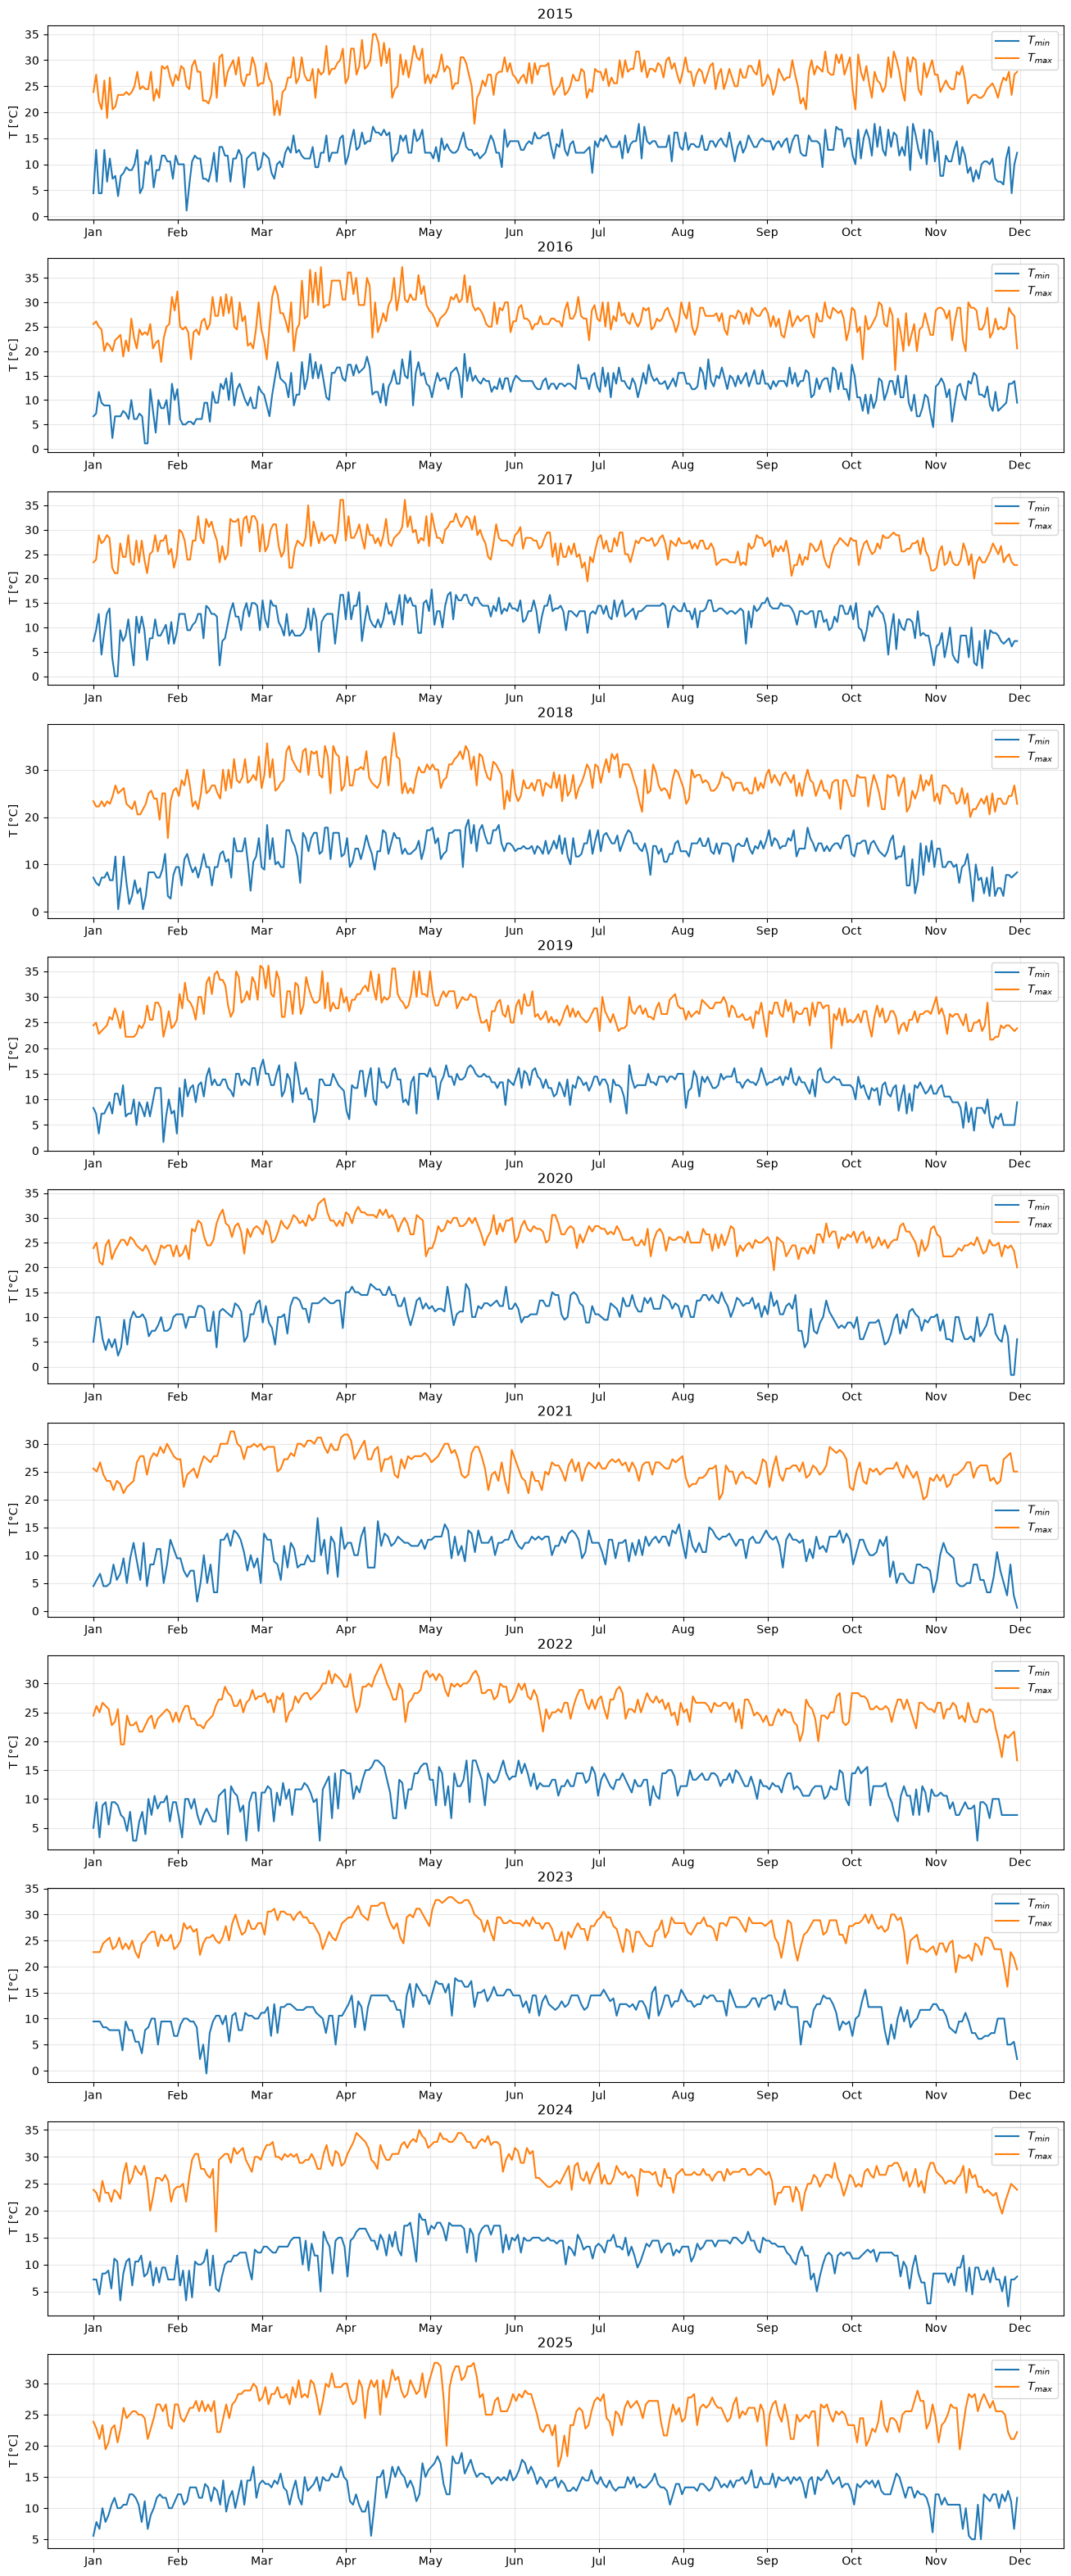

In [48]:
per_year()

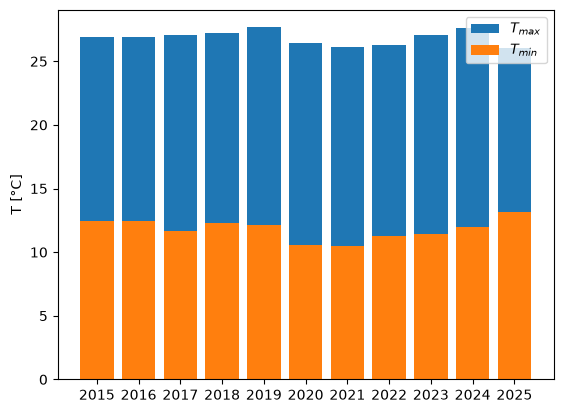

In [49]:
yearly_avg()

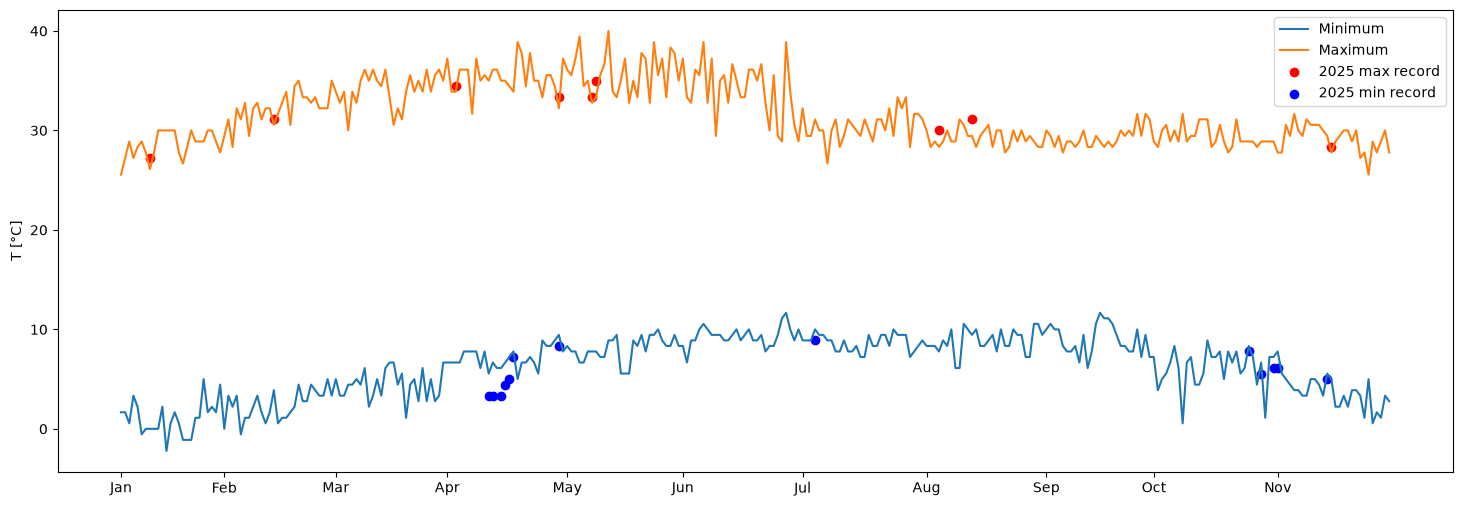

In [71]:
records()